In [1]:
# Import libraries
import numpy as np
import pandas as pd

# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import sci-kit learn libraries
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, precision_recall_fscore_support

# Import dataset
df = pd.read_csv('Iris.csv')
df.head(9)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa


In [2]:
# Check dataframe details
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [3]:
# Data preprocessing
# Delete the Id column
df = df.drop('Id', axis=1)

In [4]:
# Re-check dataframe details.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# Check how many unique values there are in the 'Species' column
df['Species'].nunique()

3

In [6]:
# Check which are the unique values in 'species' column to gain insight on its distribution
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [7]:
# Check the amonut of diferent values in the Species column
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

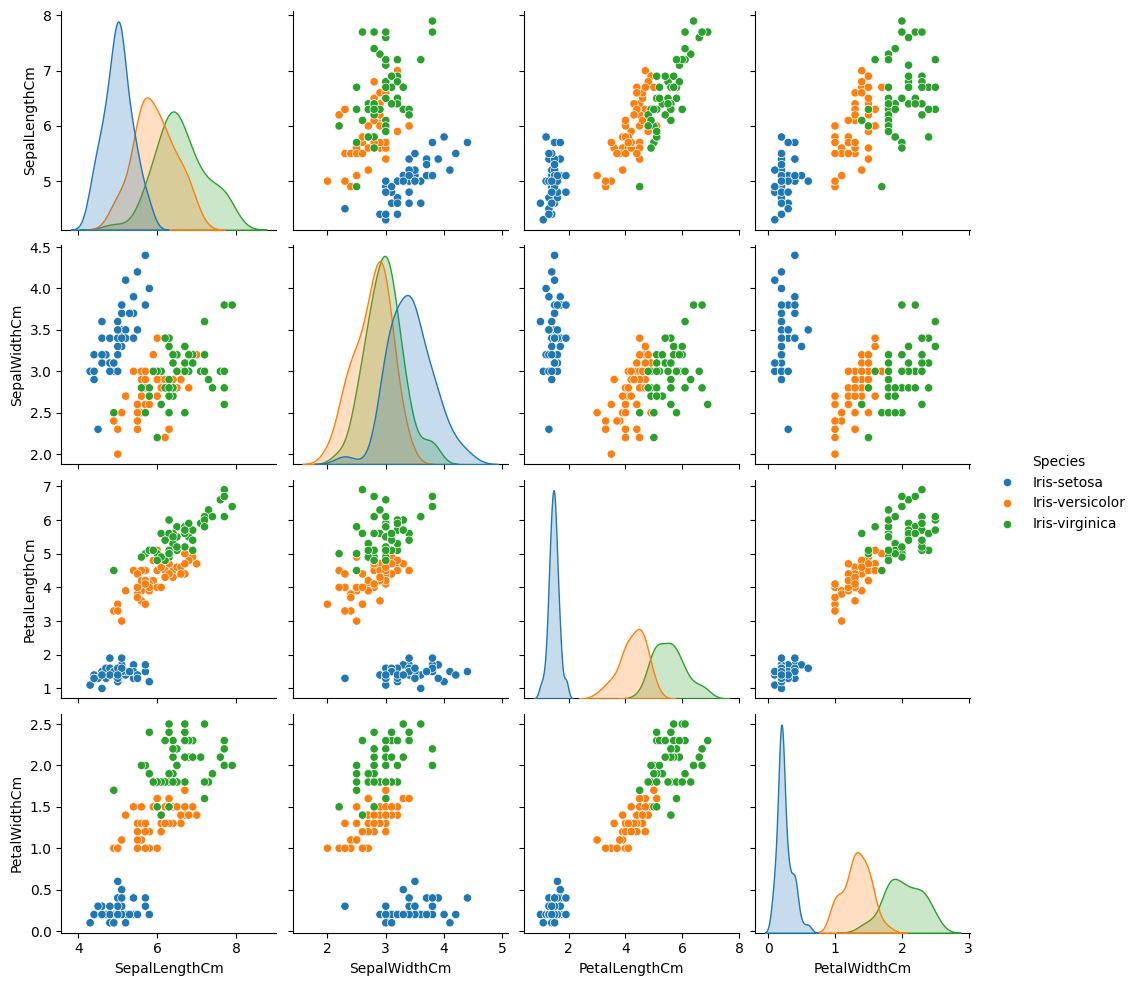

In [8]:
# Use seaborn to visualize the data and enhance comprehension
sns.pairplot(df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm', 'Species']],hue='Species')
plt.show()



It seems that Iris-setosa have lower petal width, sepal lenght and petal lenght compared to other species.

It's apparent that iris-virginica have higher sepal lenght, petal lenght and petal width compared to other species but lower lower sepal width than Iris-setosa.

It looks like Iris-versicolor stands in the middle of the three species in all characteristics but one: although not too dissimilar from Iris-virginica, it has the lowest sepal width of all the species analysed.


In [9]:
# Encode ordinal categorical values
label_mapping = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}

df['Species'] = df['Species'].map(label_mapping)

In [10]:
# Display dataset details
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [11]:
# Check the dataset
df.head(70)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
65,6.7,3.1,4.4,1.4,1
66,5.6,3.0,4.5,1.5,1
67,5.8,2.7,4.1,1.0,1
68,6.2,2.2,4.5,1.5,1


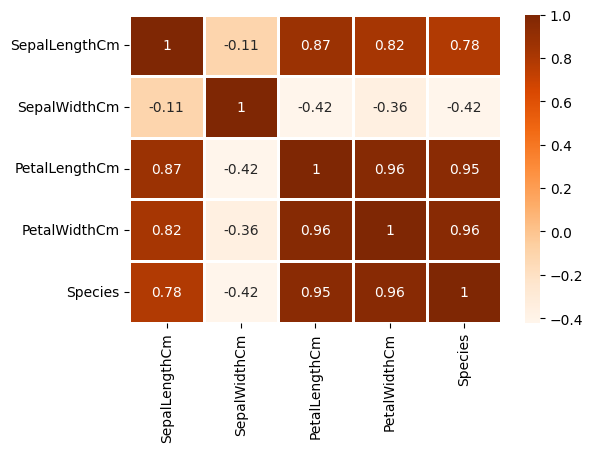

In [12]:
# Use matplotlib to create a heatmap and further analyse the data
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='Oranges', linewidths=1)
plt.show()

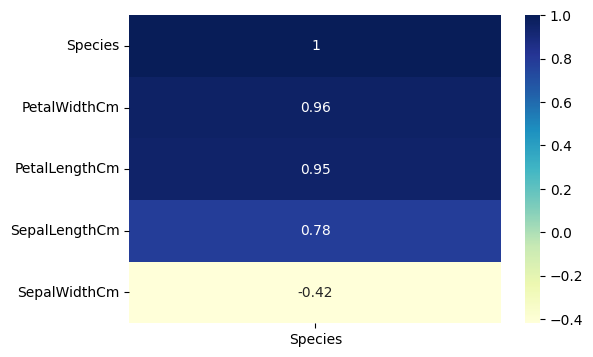

In [13]:
# Use seaborn to create a heatmap and further analyse the data
correlation = df.corr()[['Species']].sort_values(by='Species', ascending=False)
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='YlGnBu')
plt.show()

In [14]:
# Identify dependent and independent variables
X = df.drop('Species', axis=1)
y = df['Species']


In [15]:
# Split the data into training and testing sets
# We'll use 70% to train the model, 30% to test it
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} flowers")
print(f"Testing set size: {len(X_test)} flowers")

Training set size: 105 flowers
Testing set size: 45 flowers


In [16]:
# Standardize (scale) features using StandardScaler
sc_multi = StandardScaler()
X_train_sc = sc_multi.fit_transform(X_train)
X_test_sc = sc_multi.transform(X_test)

In [17]:
# Implementing Logistic Regression model
# Initialize the logistic regression model
log_reg_multi = LogisticRegression()

In [18]:
# Fit the logistic regression model
log_reg_multi.fit(X_train_sc, y_train)

LogisticRegression()

In [19]:
# Predict the model
y_pred = log_reg_multi.predict(X_test_sc)

In [20]:
# Print the Confusion Matrix
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))  # Fixed order

Confusion Matrix: 
 [[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]


<Figure size 1000x800 with 0 Axes>

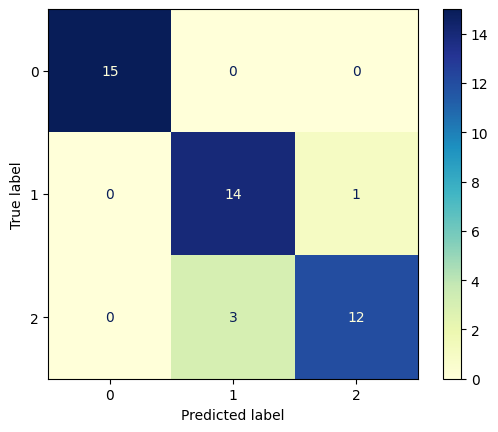

In [21]:
# Display the Confusion Matrix heatmap.
confusion_matrix_result = confusion_matrix(y_test, y_pred, labels=log_reg_multi.classes_)  # Fixed variable name conflict
display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_result, display_labels=log_reg_multi.classes_)
plt.figure(figsize=(10, 8))
display.plot(cmap='YlGnBu')
plt.show()

When analysing the Confusion Matrix we can understand that the model is likely to have similar precision and recall, as there's no cases of misclassifications. Both precision and recall showed to be very accurate in this model.

In [22]:
# Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')  # or 'weighted'
rec = recall_score(y_test, y_pred, average='macro')

print(f'Accuracy: {acc:.2f}')
print(f'Precision: {prec:.2f}')
print(f'Recall: {rec:.2f}')

Accuracy: 0.91
Precision: 0.92
Recall: 0.91


In [23]:
# Print the accuracy score
print(f"The accuracy score is: {accuracy_score(y_test, y_pred):.3f}")

The accuracy score is: 0.911


In [24]:
# Print the recall score
print(f"The recall score is: {recall_score(y_test, y_pred, average='macro'):.3f}")

The recall score is: 0.911


In [25]:
# Print the precision score
print(f"The precision score is: {precision_score(y_test, y_pred, average='macro'):.3f}")  # Fixed order and added average

The precision score is: 0.916


In [26]:
# Print the classification report
print(f"Classification report:\n\n{classification_report(y_test, y_pred)}")  # Fixed order

Classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [27]:
# Calculate metrics for multi-class classification
print("\n=== Detailed Metrics ===")
precision, recall, fscore, support = precision_recall_fscore_support(y_test, y_pred, average=None)
classes = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

for i, class_name in enumerate(classes):
    print(f"Class {class_name}:")
    print(f"  Precision: {precision[i]:.3f}")
    print(f"  Recall: {recall[i]:.3f}")
    print(f"  F1-Score: {fscore[i]:.3f}")
    print(f"  Support: {support[i]}")
    print()


=== Detailed Metrics ===
Class Iris-setosa:
  Precision: 1.000
  Recall: 1.000
  F1-Score: 1.000
  Support: 15

Class Iris-versicolor:
  Precision: 0.824
  Recall: 0.933
  F1-Score: 0.875
  Support: 15

Class Iris-virginica:
  Precision: 0.923
  Recall: 0.800
  F1-Score: 0.857
  Support: 15



The logistic regression model achieved 100% accuracy on the test set, correctly classifying all three Iris species. This suggests strong feature separability and model generalization on this dataset.